In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Import the datasets
wages_df = pd.read_csv("../datasets_cleaned/wages.csv", dtype={"noc_code": "string"})
ai_adoption_df = pd.read_csv("../datasets_cleaned/ai_adoption.csv")

# **Analyzing AI adoption across (NAICS) industries**

We have AI adoption data for 2017, 2019, and 2022 (because the Survey of Innovation and Business Strategy is conducted every three years). The cleaned dataset contains national-level AI adoption rates for major NAICS (North American Industry Classification System) industry sectors.  

`The AI adoption rate` represents the percentage of enterprises (of all sizes) within a given industry that reported using artificial intelligence.

In [26]:
# Check the summary statistics
ai_adoption_df.groupby('year')['ai_adoption_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017,14.0,4.392857,4.385372,0.8,2.100,3.10,3.925,16.8
2019,14.0,6.228571,5.947130,0.9,3.150,4.65,6.050,20.9
2022,14.0,7.814286,5.221090,2.2,4.825,5.80,7.600,18.0


The summary statistics show a clear upward trend in AI adoption rates across industries from 2017 to 2022, with the mean rising from about 4.4% in 2017 to 6.2% in 2019 and 7.8% in 2022. Despite this overall rise, the distribution remains right-skewed with high variability, signaling persistent inequality between sectors. Interestingly, the max value in 2022 is lower than in 2019, suggesting that some industry has seen a decrease in AI adoption. 

### **AI adoption rate by industry sector**

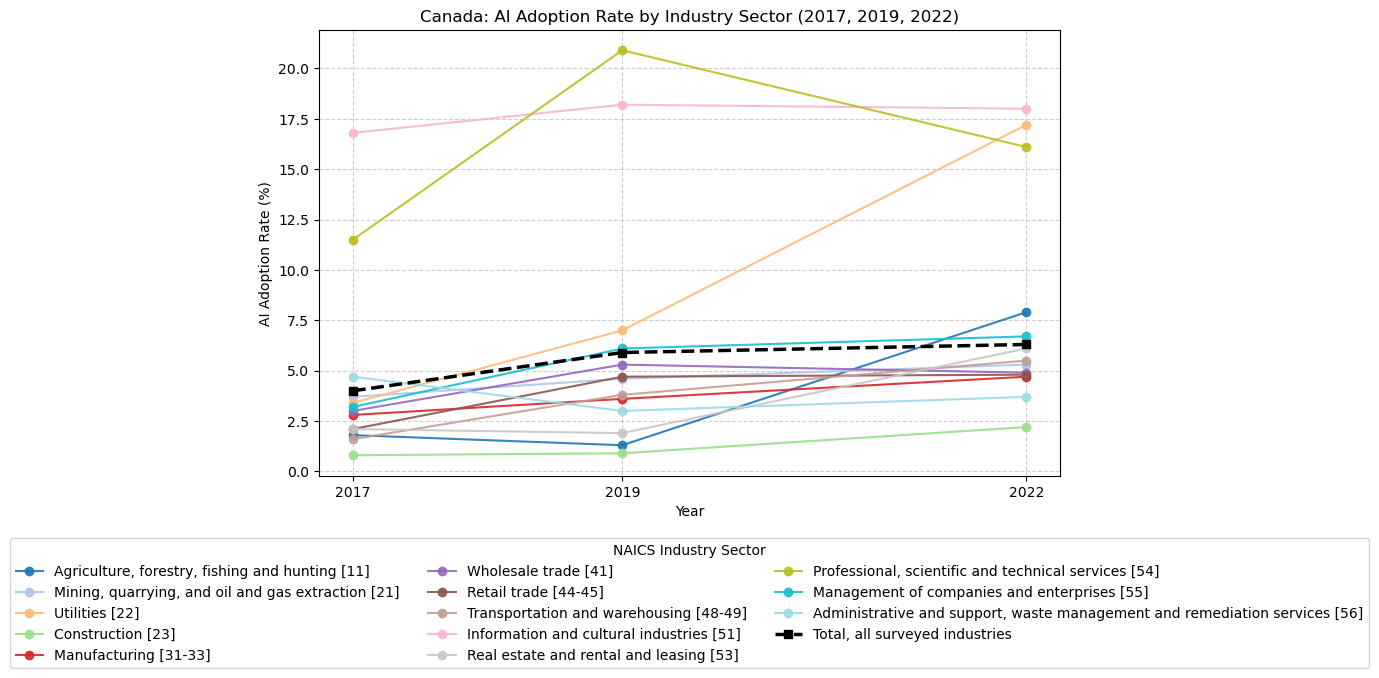

In [27]:
# Line plot: the AI adoption rate by industry sector

df_total = ai_adoption_df[ai_adoption_df['naics_sector'] == 'TOTAL'].copy()
df_sectors = ai_adoption_df[ai_adoption_df['naics_sector'] != 'TOTAL'].copy()

# Get unique sectors
sectors = df_sectors['naics_name'].unique()

# Generate distinct colours for the lines in the line plot
cmap = plt.get_cmap('tab20', len(sectors))
colors = cmap(np.arange(len(sectors)))

plt.figure(figsize=(12, 7))

# Plot individual sectors
for i, sector in enumerate(df_sectors['naics_name'].unique()):
    sector_data = df_sectors[df_sectors['naics_name'] == sector]
    plt.plot(sector_data['year'], sector_data['ai_adoption_rate'], marker='o', linestyle='-', label=sector, color=colors[i], alpha=0.9)

# Plot the total line distinctly
plt.plot(df_total['year'], df_total['ai_adoption_rate'], marker='s', linestyle='--', color='black', linewidth=2.5, label='Total, all surveyed industries')

plt.title('Canada: AI Adoption Rate by Industry Sector (2017, 2019, 2022)')
plt.xlabel('Year')
plt.ylabel('AI Adoption Rate (%)')
plt.xticks(ai_adoption_df['year'].unique())

# Place the legend at the bottom of the graph
plt.legend(title='NAICS Industry Sector', bbox_to_anchor=(0.5, -0.125), loc='upper center', ncol=3, fancybox=True)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

The national average (black dashed line) shows a steady but slow rise in AI adoption, increasing from roughly 4% to 6%.  

The consistent leaders throughout 2017–2022 are the `Information and cultural industries` and the `Professional, scientific, and technical services` sector, although the latter shows a slight decline in the final period. `Utilities` experienced the most dramatic growth, rising from about 3% in 2017 to roughly 17.4% in 2022. Together, these three sectors stand out as the most significant AI adopters by 2022, with all other sectors having AI adoption rate of <10%.

# **Analyzing Canadian wage trends**

We have high, meidan and low wage data for ~510 occupations in Canada, spanning the years 2012 to 2024.

(Although AI adoption data is only available from 2017 to 2022, we decided to analyze the full 2012 – 2024 wage period. A vertical line at 2017 was added to all line plots to easily track wage trends that correspond with the available AI adoption data.)

The wage data is later aggregated by major NOC group (based on the first digit of the NOC code), allowing individual occupations to be grouped into a manageable number of broad categories. Moreover, this grouping helps dealing with changes to the NOC classification over the years. Since the major NOC categories remain highly consistent, experiencing only slight name changes, this method ensures the long-term data series is comparable and coherent for analyzing wage trends.

### **Wage trends across all occupations**

In [28]:
# Group by year and occupation to get proper national averages
wage_trends = wages_df.groupby(['year', 'noc_title']).agg({'low_wage': 'first', 'median_wage': 'first', 'high_wage': 'first'}).reset_index()

# Calculate the mean across all occupations for each year
wage_trends = wage_trends.groupby('year').agg({'low_wage': 'mean', 'median_wage': 'mean', 'high_wage': 'mean'}).reset_index()

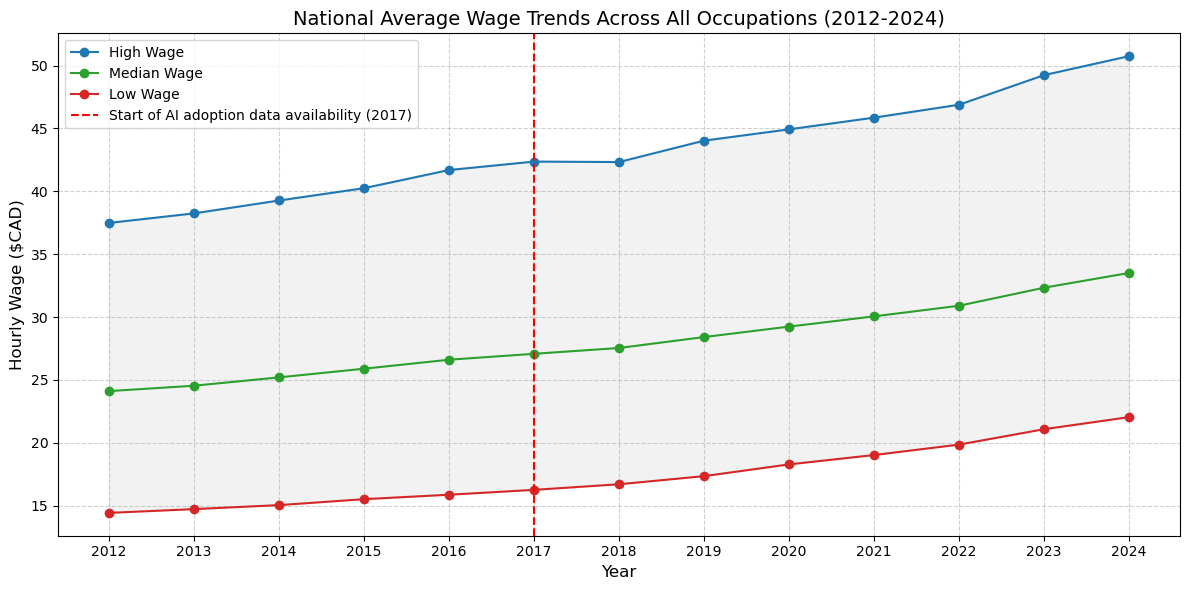

In [29]:
# Create the plot
plt.figure(figsize=(12, 6))

# Plot the lines
plt.plot(wage_trends['year'], wage_trends['high_wage'], label='High Wage', color='#1f77b4', marker='o')
plt.plot(wage_trends['year'], wage_trends['median_wage'], label='Median Wage', color='#2ca02c', marker='o')
plt.plot(wage_trends['year'], wage_trends['low_wage'], label='Low Wage', color='#d62728', marker='o')

# Add AI introduction line
plt.axvline(x=2017, color='red', linestyle='--', label='Start of AI adoption data availability (2017)')

# Fill between the lines
plt.fill_between(wage_trends['year'], wage_trends['low_wage'], wage_trends['high_wage'], color='gray', alpha=0.1)

# Customize the plot
plt.title('National Average Wage Trends Across All Occupations (2012-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Hourly Wage ($CAD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(wage_trends['year'])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

All three wage metrics (High Wage, Median Wage, and Low Wage) show a clear, consistent upward trend over the entire 13-year period. There are no notable drops/no major change in the wage curves is evident after the 2017 year mark.

### **Wage trends for the different NOC categories**

As noted above, we aggregate wage data by major NOC occupational categories, grouping individual occupations based on the first digit of their NOC code. This approach reduces the number of categories to a manageable set of broad groups, smoothing out occupation-specific variability and facilitating the comparison of wage trends with AI adoption rates across NAICS industry sectors.

In [30]:
# --- MAPPING: 1-ST NOC CODE DIGIT to MAJOR NOC GROUP NAME  ---

noc_names = {
    "0": "Legislative and senior management occupations",
    "1": "Business, finance and administration",
    "2": "Natural and applied sciences",
    "3": "Health occupations",
    "4": "Education, law, social, community and government services",
    "5": "Art, culture, recreation and sport",
    "6": "Sales and service",
    "7": "Trades, transport and equipment operators",
    "8": "Natural resources, agriculture",
    "9": "Manufacturing and utilities"
}

In [31]:
# Wages data preparation

# Define the wage columns
wage_cols = ['low_wage', 'median_wage', 'high_wage']

# Extract the first digit of the NOC code to get the broad occupational category
wages_df['major_noc_group'] = wages_df['noc_code'].str[0]
# Add NOC names for readability
wages_df['noc_name'] = wages_df['major_noc_group'].map(noc_names)

# Group by year and NOC category, calculating the mean hourly wage for each group.
# We use mean() because there can be multiple 4-digit NOC codes within one 1-digit category.
wages_agg_df = wages_df.groupby(['year', 'major_noc_group', 'noc_name' ])[wage_cols].mean().reset_index()

wages_agg_df.head()

,year,major_noc_group,noc_name,low_wage,median_wage,high_wage
0,2012,0,Legislative and senior management occupations,20.080455,36.892727,57.594318
1,2012,1,"Business, finance and administration",13.001786,20.853214,31.817143
2,2012,2,Natural and applied sciences,18.170159,30.357619,48.255238
3,2012,3,Health occupations,17.084486,31.056186,50.484229
4,2012,4,"Education, law, social, community and governme...",16.467931,29.195638,47.133017


#### **Low wage trends**

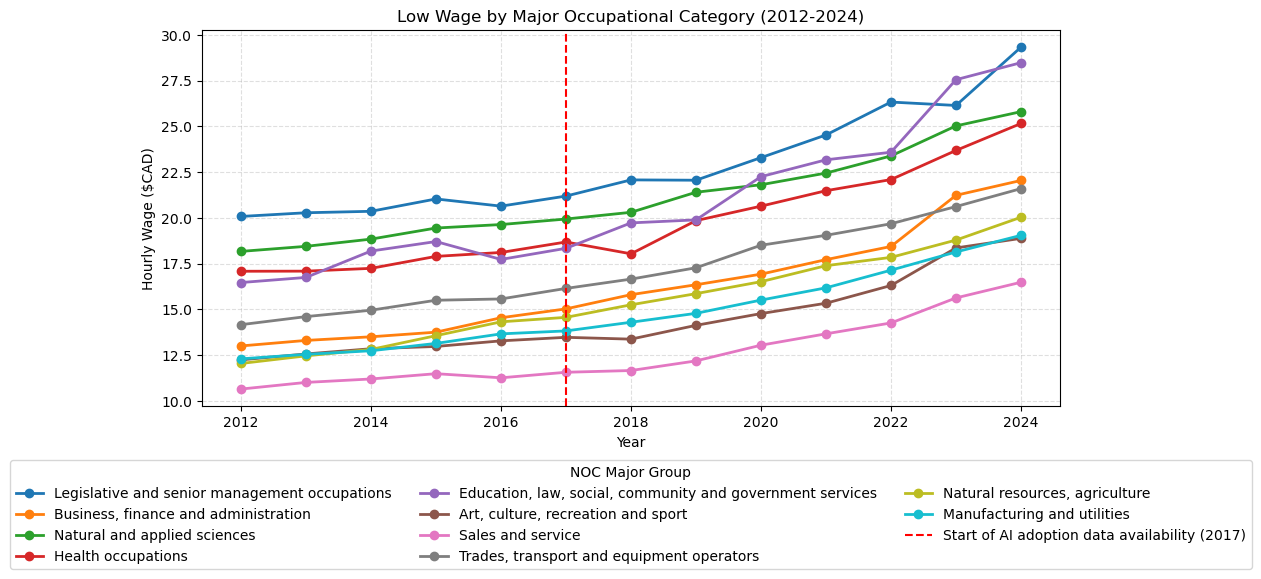

In [32]:
# --- LOW WAGE PLOT ---

plt.figure(figsize=(12, 6))

# Plot line for each group
for noc in noc_names.keys():
    group_data = wages_agg_df[wages_agg_df['major_noc_group'] == noc]
    plt.plot(group_data['year'], group_data['low_wage'], marker='o', linewidth=2, label=group_data['noc_name'].unique())

# Add AI introduction line
plt.axvline(x=2017, color='red', linestyle='--', label='Start of AI adoption data availability (2017)')

plt.title("Low Wage by Major Occupational Category (2012-2024)")
plt.xlabel("Year")
plt.ylabel("Hourly Wage ($CAD)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='NOC Major Group', bbox_to_anchor=(0.5, -0.125), loc='upper center', ncol=3, fancybox=True)

plt.tight_layout()
plt.show()

This plot shows consistent upward growth in low hourly wages across all major occupational categories from 2012 to 2024. `Legislative and senior management` consistently maintain the highest low wage (ending near $30/hour), while `Sales and service consistently remain the lowest` (ending near $16/hour).

#### **Median wage trends**

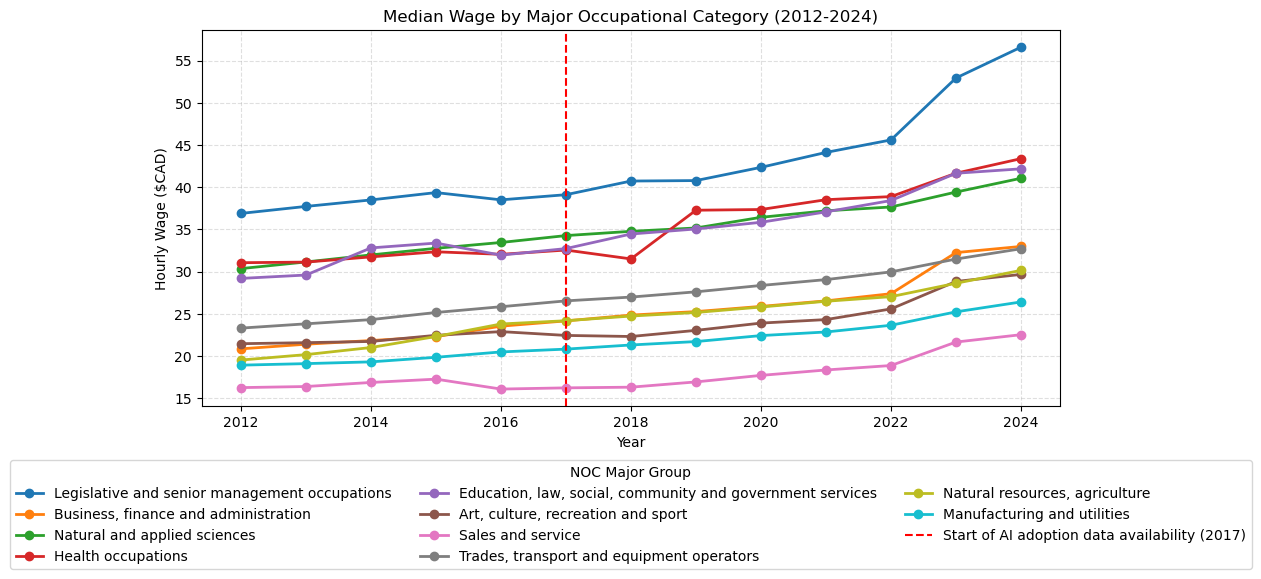

In [33]:
# --- MEDIAN WAGE PLOT ---

plt.figure(figsize=(12, 6))

# Plot line for each group
for noc in noc_names.keys():
    group_data = wages_agg_df[wages_agg_df['major_noc_group'] == noc]
    plt.plot(group_data['year'], group_data['median_wage'], marker='o', linewidth=2, label=group_data['noc_name'].unique())

# Add AI introduction line
plt.axvline(x=2017, color='red', linestyle='--', label='Start of AI adoption data availability (2017)')

plt.title("Median Wage by Major Occupational Category (2012-2024)")
plt.xlabel("Year")
plt.ylabel("Hourly Wage ($CAD)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='NOC Major Group', bbox_to_anchor=(0.5, -0.125), loc='upper center', ncol=3, fancybox=True)

plt.tight_layout()
plt.show()

Median wages grew across all major occupational categories from 2012 to 2024. A clear leader emerges: `Legislative and senior management` demonstrates the steepest growth (particularly after 2022), reaching approximately $55/hour and highlighting wage polarization. `Sales and service` consistently maintains the lowest median wages. Meanwhile, `Health`, `Education, law, social, community, and government services`, and `Natural and applied sciences` form a tight middle cluster, ending in the $40–45/hour range.

#### **High wage trends**

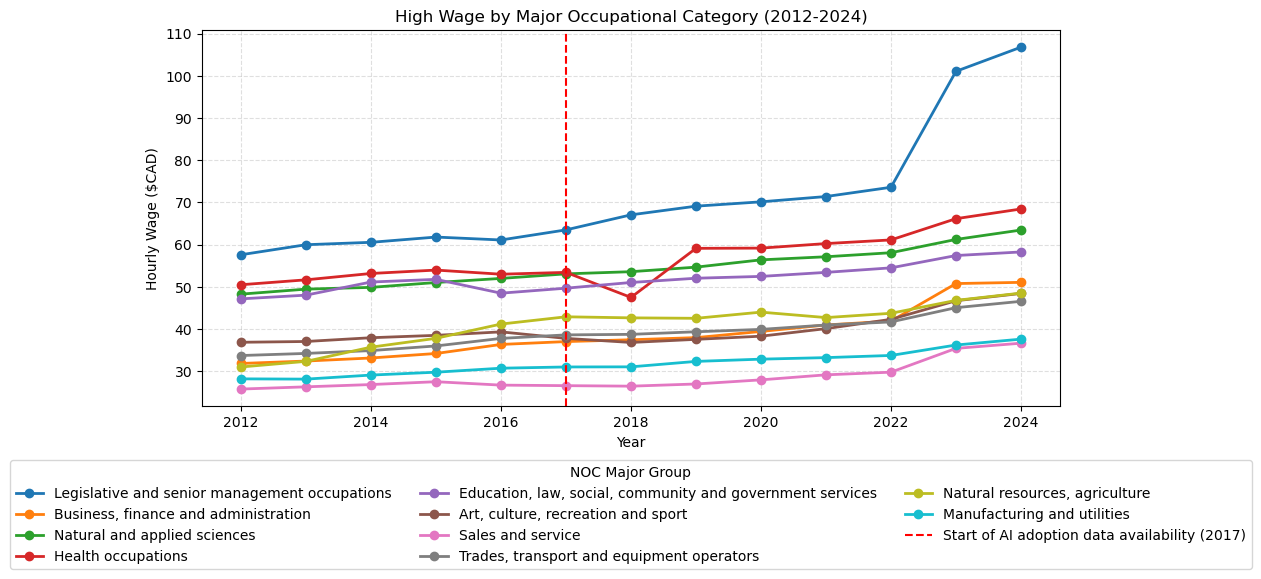

In [34]:
# --- HIGH WAGE PLOT ---

plt.figure(figsize=(12, 6))

# Plot line for each group
for noc in noc_names.keys():
    group_data = wages_agg_df[wages_agg_df['major_noc_group'] == noc]
    plt.plot(group_data['year'], group_data['high_wage'], marker='o', linewidth=2, label=noc_names[noc])

# Add AI introduction line
plt.axvline(x=2017, color='red', linestyle='--', label='Start of AI adoption data availability (2017)')

plt.title("High Wage by Major Occupational Category (2012-2024)")
plt.xlabel("Year")
plt.ylabel("Hourly Wage ($CAD)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='NOC Major Group', bbox_to_anchor=(0.5, -0.125), loc='upper center', ncol=3, fancybox=True)

plt.tight_layout()
plt.show()

The plot clearly demonstrates significant wage polarization. `Legislative and senior management occupations` show extreme and accelerating growth, (especially after 2022), rising from around $60/hour in 2017 to over $100/hour by 2024. This trend sharply separates this group from all others.`Health`, `Education, law, social, community, and government services`, and `Natural and applied sciences` once again form a middle cluster ending in ~$60-70/hour range. In contrast, `Manufacturing and utilities` and `Sales and service` have the lowest high-end wages, remaining under $40/hour.

##### **Observed patterns**

- **Legislative senior management occupations:** `Legislative and senior management` occupations consistently lead across all wage categories and accelerate sharply after 2022 in median and high wages, with high-end wages surpassing $100/hour by 2024, fully decoupling from the rest of the workforce.

- **High education cluster:** `Health`; `Education, law, social, community, and government services`; and `Natural and applied sciences` form a tight middle tier that consistently follows senior management, with stable wage floors and ceilings. Notably, these three occupational categories typically have higher education requirements.

- **Persistent Lower-Wage Tier:** `Sales and service`, `Manufacturing and utilities`, and `Art/Culture` remain anchored at the bottom across all charts, with `Sales and service` showing the lowest wages in every metric.

> **Note regarding median and high wages for health occupations in 2018:** The visible dip in high and median wages in 2018 could be attributed to data suppression. Our analysis reveals that the 2018 dataset contains fewer occupational observations (N=498) compared to adjacent years, excluding specific high-wage professions like `specialist physicians` and `general practitioners and family physicians`. This is most likely a statistical artifact, not a reflection of a contraction in market wages.

### **Wage growth for different NOC categories (2017 - 2022): Net and % change**

We have restricted the wage growth analysis to the 2017–2022 period to align strictly with the available AI adoption data, which is present for 2017, 2019, and 2022.

In [35]:
# Create a color map for all NOC groups
all_nocs = wages_agg_df["major_noc_group"].unique()
cmap = plt.get_cmap("tab10", len(all_nocs))
color_map = {noc: cmap(i) for i, noc in enumerate(all_nocs)}

#### **Low Wage**

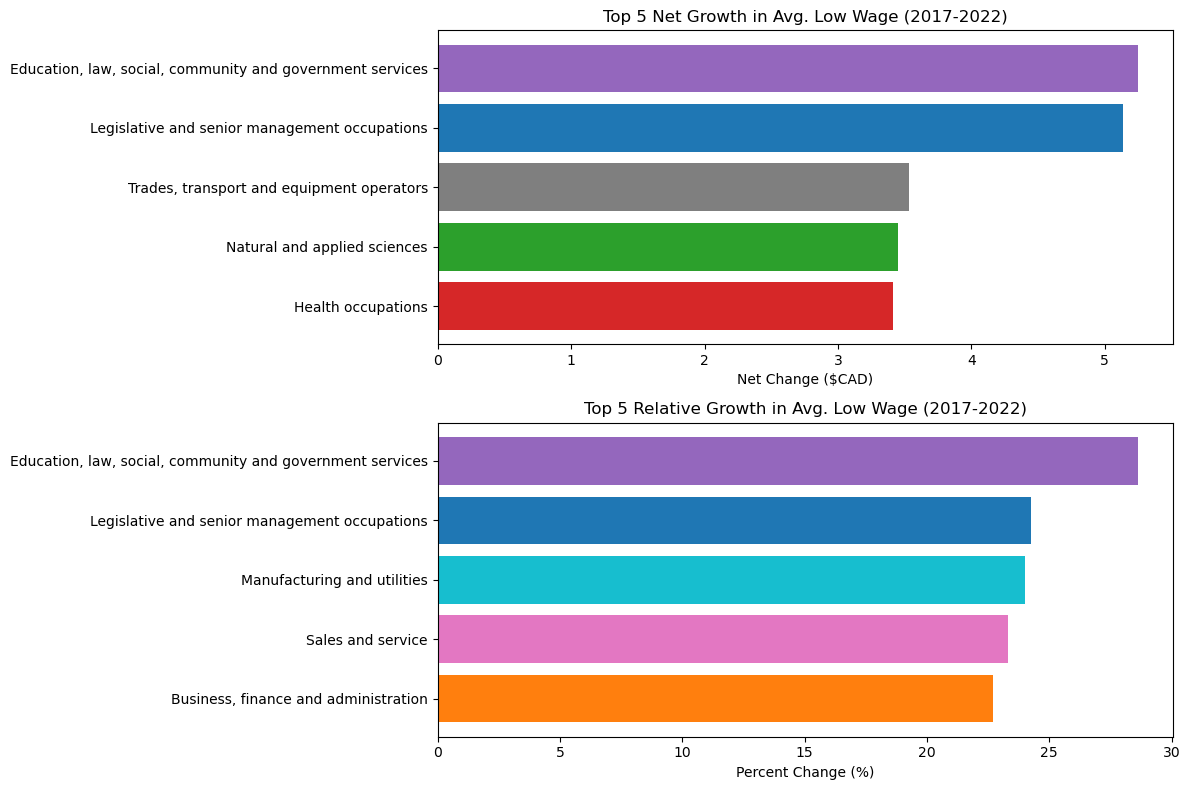

In [36]:
# Pivot low_wage for relevant years
low_wages = wages_agg_df.pivot_table(index=["major_noc_group", "noc_name"], columns="year", values="low_wage")

# Compute change
low_change = (low_wages[2022] - low_wages[2017]).reset_index(name="net_change")
low_pct = ((low_wages[2022] - low_wages[2017]) / low_wages[2017] * 100).reset_index(name="pct_change")

# Sort and take top 5
top_low_net = low_change.sort_values("net_change", ascending=False).head(5)
top_low_pct = low_pct.sort_values("pct_change", ascending=False).head(5)

# Plot the bar chart
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].barh(top_low_net["noc_name"], top_low_net["net_change"], color=[color_map[n] for n in top_low_net["major_noc_group"]])
axes[0].set_title("Top 5 Net Growth in Avg. Low Wage (2017-2022)")
axes[0].set_xlabel("Net Change ($CAD)")
axes[0].invert_yaxis()

axes[1].barh(top_low_pct["noc_name"], top_low_pct["pct_change"], color=[color_map[n] for n in top_low_pct["major_noc_group"]])
axes[1].set_title("Top 5 Relative Growth in Avg. Low Wage (2017-2022)")
axes[1].set_xlabel("Percent Change (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### **Median Wage**

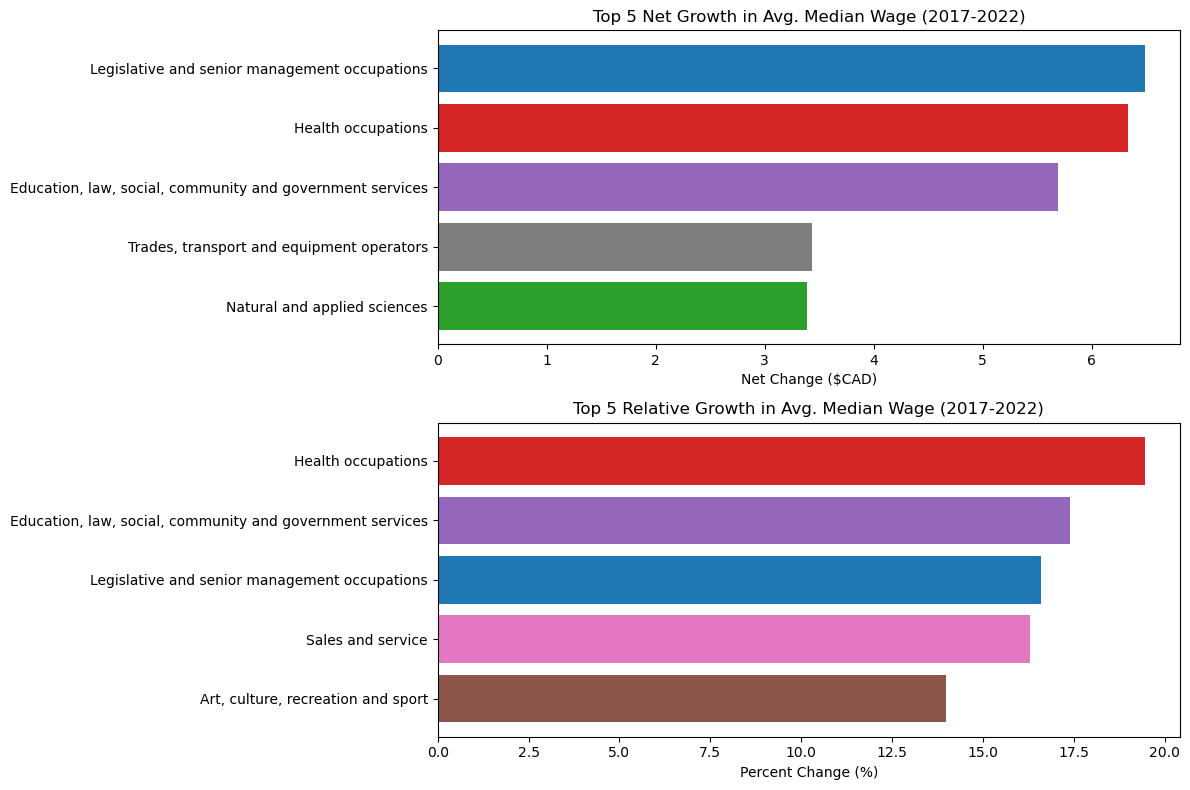

In [37]:
# Pivot median_wage for relevant years
median_wages = wages_agg_df.pivot_table(index=["major_noc_group", "noc_name"], columns="year", values="median_wage")

# Compute change
median_change = (median_wages[2022] - median_wages[2017]).reset_index(name="net_change")
median_pct = ((median_wages[2022] - median_wages[2017]) / median_wages[2017] * 100).reset_index(name="pct_change")

# Top 5
top_median_net = median_change.sort_values("net_change", ascending=False).head(5)
top_median_pct = median_pct.sort_values("pct_change", ascending=False).head(5)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].barh(top_median_net["noc_name"], top_median_net["net_change"], color=[color_map[n] for n in top_median_net["major_noc_group"]])
axes[0].set_title("Top 5 Net Growth in Avg. Median Wage (2017-2022)")
axes[0].set_xlabel("Net Change ($CAD)")
axes[0].invert_yaxis()

axes[1].barh(top_median_pct["noc_name"], top_median_pct["pct_change"], color=[color_map[n] for n in top_median_pct["major_noc_group"]])
axes[1].set_title("Top 5 Relative Growth in Avg. Median Wage (2017-2022)")
axes[1].set_xlabel("Percent Change (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

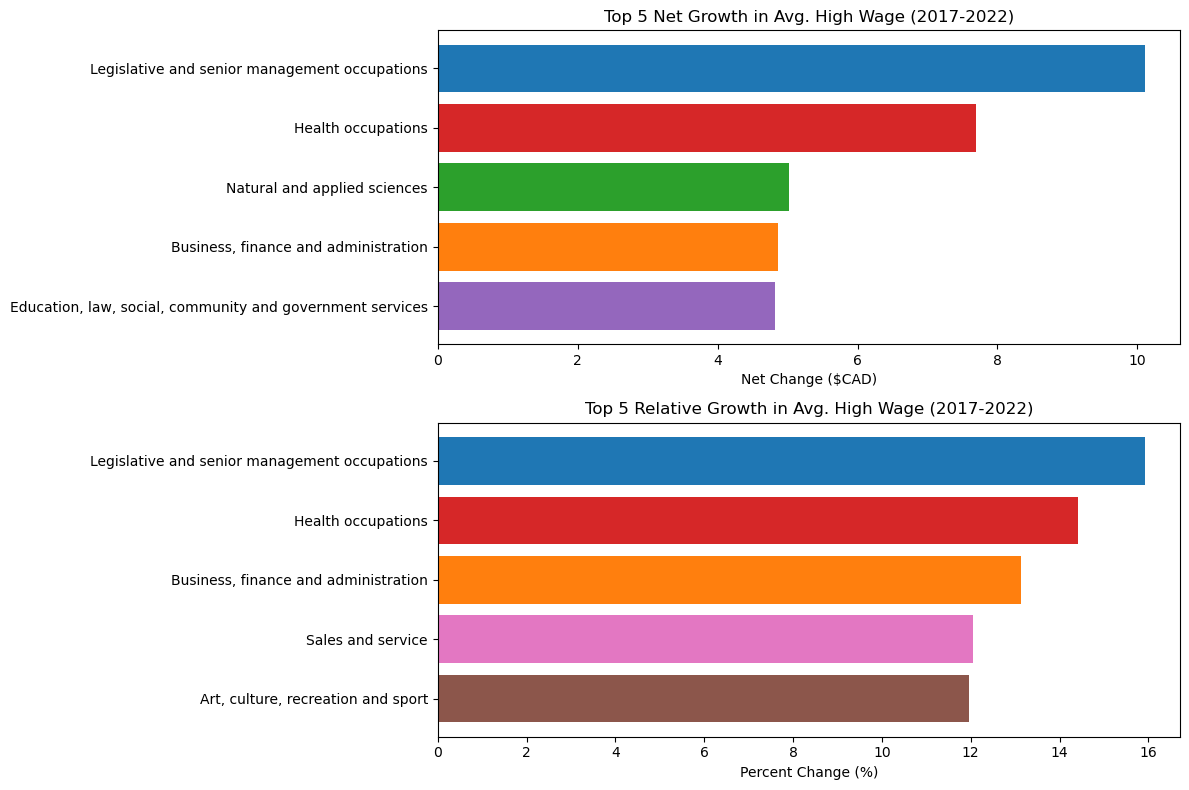

In [38]:
# Pivot high_wage for relevant years
high_wages = wages_agg_df.pivot_table(index=["major_noc_group", "noc_name"], columns="year", values="high_wage")

# Compute change
high_change = (high_wages[2022] - high_wages[2017]).reset_index(name="net_change")
high_pct = ((high_wages[2022] - high_wages[2017]) / high_wages[2017] * 100).reset_index(name="pct_change")

# Top 5
top_high_net = high_change.sort_values("net_change", ascending=False).head(5)
top_high_pct = high_pct.sort_values("pct_change", ascending=False).head(5)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].barh(top_high_net["noc_name"], top_high_net["net_change"], color=[color_map[n] for n in top_high_net["major_noc_group"]])
axes[0].set_title("Top 5 Net Growth in Avg. High Wage (2017-2022)")
axes[0].set_xlabel("Net Change ($CAD)")
axes[0].invert_yaxis()

axes[1].barh(top_high_pct["noc_name"], top_high_pct["pct_change"], color=[color_map[n] for n in top_high_pct["major_noc_group"]])
axes[1].set_title("Top 5 Relative Growth in Avg. High Wage (2017-2022)")
axes[1].set_xlabel("Percent Change (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

##### **Observed patterns**

**2017 - 2022**

1. **$CAD Increase (Net Wage)**
    - `Legislative & senior management`: Top 5 in all categories. Dominating the growth at high end by a large margin.
    - `Education, law, social & government services`: Leading growth for low wages. Top 5 in all categories.
    - `Health occupations`: Strong growth, top 5 in all categories, and №2 for both Median and High earners.
    - `Natural and applied sciences`: Consistent growth, in top 5 across all levels.

2. **Relative Increase (%)**
    - `Legislative & Senior Management`: Dominating the growth at high end, top 3 across all levels.
    - `Education, law, social & government services`: Among the top 5 in low and median wages, strongly dominating the low wage growth.
    - `Health occupations`: High growth for median and high wages (№1 leader in percentage growth for median wages).  
    - `Sales & Service`: Among top 5 in all categories, though net increases remain small due to small starting wages.
    - `Business, Finance & Administration`: Strong low and high wage percentage growth.


## **Analyzing relationship between Canadian wages and AI adoption**

To analyze the relationship between Canadian wages and AI adoption, we needed to find a way to relate two datasets that use different classification systems: the wage data organized by National Occupational Classification (NOC) codes and the AI adoption data organized by North American Industry Classification System (NAICS) sectors.

To do so we created a comprehensive mapping that connects NOC major categories (identified by the first digit of the NOC code) to their corresponding NAICS sectors based on where workers in each occupation are predominantly employed. We chose to focus on the first digit of NOC codes because this major category level has remained relatively stable across NOC revisions.  

- Where no clear industry match existed in our AI adoption dataset—such as NOC 3 (Health occupations) and NOC 4 (Education, law and social services),these categories were excluded from the analysis.  

- For NOC categories mapped to multiple NAICS sectors, we decided to calculate the average AI adoption rate across those sectors to represent the overall AI exposure for workers in that occupation group.

> **Methodological limiations** : While aggregating wages by NOC major groups enables a viable high-level comparison with industry-based AI adoption data, this approach introduces aggregation bias by hiding variability within broad occupational categories. For instance, the "Natural and Applied Sciences" group combines highly exposed roles like software engineers with less exposed roles like biologists, potentially diluting specific wage signals. Additionally, mapping occupations to specific primary industries assumes a rigid workforce structure that does not account for cross-sectoral employment (e.g., administrative staff working in the construction sector). Finally, the exclusion of the Health and Education sectors due to data unavailability limits the analysis to market-driven industries and may not fully represent the entire Canadian labor landscape.

In [39]:
# --- MAPPING: NOC to NAICS ---

noc_to_naics = {
    "0": ["55"],             # Management → Management of companies (direct match)
    "1": ["54", "55", "56"], # Business/Finance/Admin → Professional services + Management + Administrative support (strong fits)
    "2": ["31-33", "54"],    # Natural & Applied Sciences → Manufacturing + Professional/technical (engineers in both)
    "3": [],    # Health industry - no health sector in AI dataset
    "4": [],    # Education/Law/Social - no good match among major industry sectors in AI dataset (missing direct match)
    "5": ["51"],                # Arts/Culture/Recreation → Information & cultural industries (direct match)
    "6": ["41", "44-45", "53"], # Sales & Service → Wholesale + Retail + Real estate (major employers)
    "7": ["23", "48-49"],       # Trades/Transport → Construction + Transportation (both major employers)
    "8": ["11", "21"],          # Natural Resources/Agriculture → Agriculture + Mining (both extractive industries)
    "9": ["22", "31-33"]        # Manufacturing/Utilities → Utilities + Manufacturing (direct match)
}

#### **Combine the wages and AI adoption data in the single Data Frame for further analysis**

In [40]:
wages_noc_ai_df = wages_agg_df[wages_agg_df['year'].isin([2017, 2019, 2022])].copy()

# Map each NOC to its list of NAICS sectors
wages_noc_ai_df['naics_list'] = wages_noc_ai_df['major_noc_group'].map(noc_to_naics)

# Remove records corresponding to NOCs with no NAICS mapping (NOC 3 and 4 in the dictionary)
wages_noc_ai_df = wages_noc_ai_df[wages_noc_ai_df['naics_list'].apply(lambda x: len(x) > 0)]

wages_noc_ai_df.head()

,year,major_noc_group,noc_name,low_wage,median_wage,high_wage,naics_list
50,2017,0,Legislative and senior management occupations,21.194198,39.109927,63.489104,[55]
51,2017,1,"Business, finance and administration",15.027407,24.164444,37.006852,"[54, 55, 56]"
52,2017,2,Natural and applied sciences,19.939839,34.267903,53.061935,"[31-33, 54]"
55,2017,5,"Art, culture, recreation and sport",13.473379,22.443439,37.764333,[51]
56,2017,6,Sales and service,11.562991,16.233481,26.555917,"[41, 44-45, 53]"


In [41]:
# Function to calculate average AI adoption rate across all mapped NAICS sectors
def get_average_ai_adoption(row, ai_df):
    """Get average AI adoption rate across all NAICS sectors for this NOC."""
    year = row['year']
    naics_list = row['naics_list']
    
    # Get AI adoption for all relevant NAICS sectors in this year
    ai_values = ai_df[(ai_df['year'] == year) & (ai_df['naics_sector'].isin(naics_list))]['ai_adoption_rate'].values
    
    if len(ai_values) > 0:
        return ai_values.mean()
    else:
        return np.nan

In [42]:
wages_noc_ai_df['ai_adoption_rate'] = wages_noc_ai_df.apply(lambda row: get_average_ai_adoption(row, ai_adoption_df), axis=1)

# Sort and display
wages_noc_ai_df = wages_noc_ai_df.sort_values(['year', 'major_noc_group']).reset_index(drop=True)

print("Final Merged Analysis Data Frame:")
wages_noc_ai_df.head()

Final Merged Analysis Data Frame:


,year,major_noc_group,noc_name,low_wage,median_wage,high_wage,naics_list,ai_adoption_rate
0,2017,0,Legislative and senior management occupations,21.194198,39.109927,63.489104,[55],3.200000
1,2017,1,"Business, finance and administration",15.027407,24.164444,37.006852,"[54, 55, 56]",6.466667
2,2017,2,Natural and applied sciences,19.939839,34.267903,53.061935,"[31-33, 54]",7.150000
3,2017,5,"Art, culture, recreation and sport",13.473379,22.443439,37.764333,[51],16.800000
4,2017,6,Sales and service,11.562991,16.233481,26.555917,"[41, 44-45, 53]",2.400000


### **AI adoption in different NOC categories**

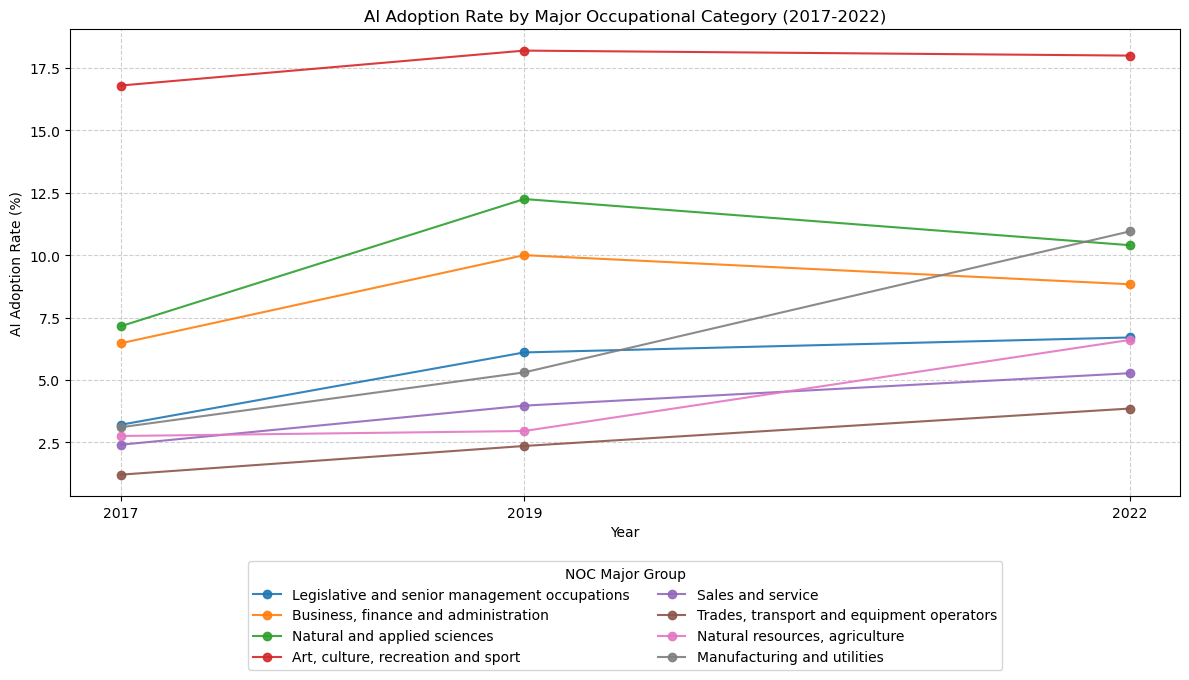

In [43]:
# Create Line Plot
plt.figure(figsize=(12, 7))

# Plot each NOC group
for noc in wages_noc_ai_df['noc_name'].unique():
    group_data = wages_noc_ai_df[wages_noc_ai_df['noc_name'] == noc]
    plt.plot(group_data['year'], group_data['ai_adoption_rate'], marker='o', linestyle='-', label=noc,alpha=0.9)

plt.title("AI Adoption Rate by Major Occupational Category (2017-2022)")
plt.xlabel("Year")
plt.ylabel("AI Adoption Rate (%)")
plt.xticks(sorted(wages_noc_ai_df['year'].unique()))

# Legend placed at bottom
plt.legend(title="NOC Major Group", bbox_to_anchor=(0.5, -0.125), loc="upper center", ncol=2, fancybox=True)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

`Manufacturing and utilities` occupational group is a clear leader in AI adoption growth.

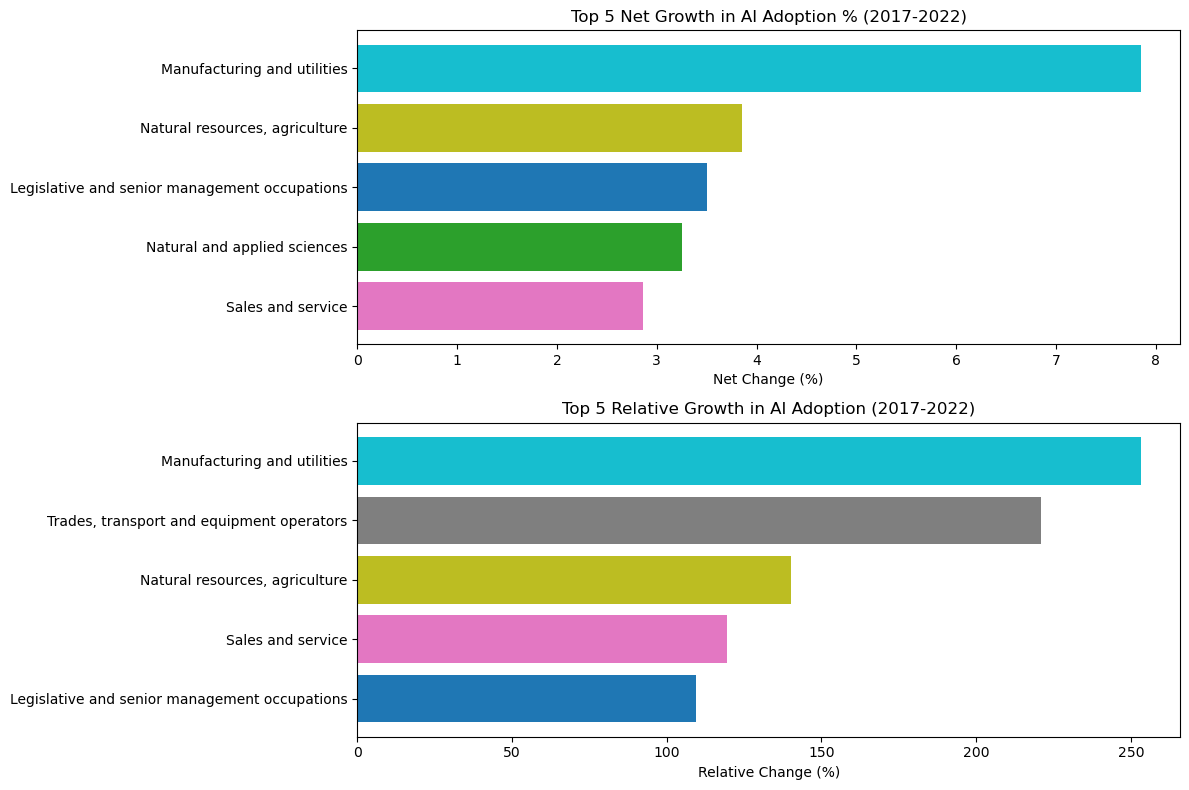

In [44]:
# Pivot table for 2017–2024
ai_pivot = wages_noc_ai_df.pivot_table( index=["major_noc_group", "noc_name"], columns="year", values="ai_adoption_rate")

# Compute growth
ai_net_change = (ai_pivot[2022] - ai_pivot[2017]).reset_index(name="net_growth")
ai_pct_change = ((ai_pivot[2022] - ai_pivot[2017]) / ai_pivot[2017] * 100).reset_index(name="pct_growth")

# Sort & pick top 5
top_ai_net = ai_net_change.sort_values("net_growth", ascending=False).head(5)
top_ai_pct = ai_pct_change.sort_values("pct_growth", ascending=False).head(5)

# Create Bar chart
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top 5 Net Growth
axes[0].barh(top_ai_net["noc_name"], top_ai_net["net_growth"], color=[color_map[n] for n in top_ai_net["major_noc_group"]])
axes[0].set_title("Top 5 Net Growth in AI Adoption % (2017-2022)")
axes[0].set_xlabel("Net Change (%)")
axes[0].invert_yaxis()

# Top 5 Percent Growth
axes[1].barh(top_ai_pct["noc_name"], top_ai_pct["pct_growth"], color=[color_map[n] for n in top_ai_pct["major_noc_group"]] )
axes[1].set_title("Top 5 Relative Growth in AI Adoption (2017-2022)")
axes[1].set_xlabel("Relative Change (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

When we compare the top AI-adopting occupational categories with those showing the largest increases in hourly wages, we find little direct correspondence. Generally, the occupations with the fastest AI adoption are not the same ones exhibiting the highest wage growth.

### **Scatterplot: Relationship between median wage and AI adoption rate**

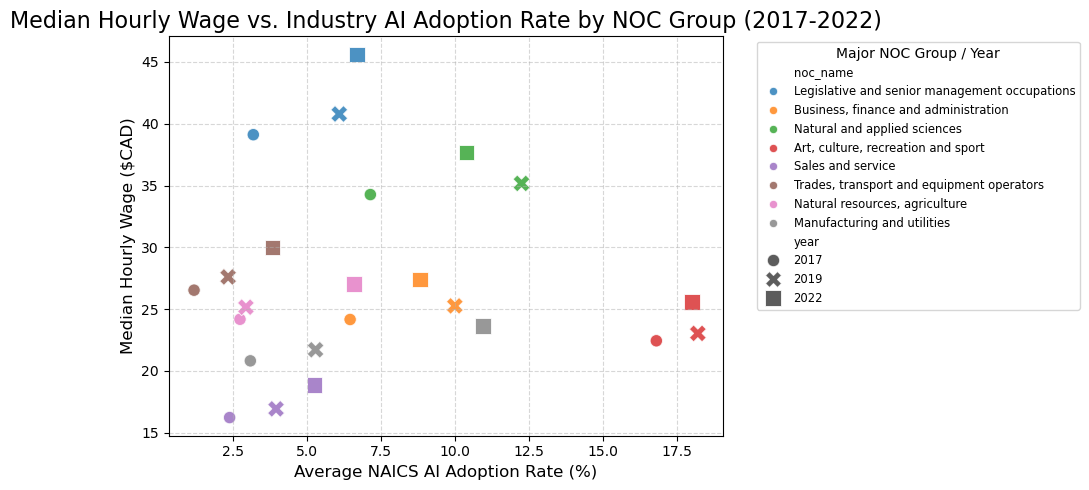

In [45]:
plt.figure(figsize=(10, 5))

# Create the scatter plot using Seaborn
sns.scatterplot(data=wages_noc_ai_df, x='ai_adoption_rate',y='median_wage', alpha=0.8,
    hue='noc_name',        # Use color to distinguish between NOC categories
    size='year',           # Use marker size to show the trend over time (2017 vs 2022),
    sizes=(80, 250),
    style='year'           # Use marker style (shape) to further distinguish the years
)

# Set plot details
plt.title('Median Hourly Wage vs. Industry AI Adoption Rate by NOC Group (2017-2022)', fontsize=16)
plt.ylabel('Median Hourly Wage ($CAD)', fontsize=12)
plt.xlabel('Average NAICS AI Adoption Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(title='Major NOC Group / Year', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

The scatterplot shows no evident linear relationship between the median hourly rate and the industry's average rate of AI adoption.

### **Checking correlation**

In [46]:
print("--- Correlation Analysis: Wages vs. AI Adoption Rate ---")

# Calculate the correlation matrix for all wage columns and AI adoption rate
correlation_matrix = wages_noc_ai_df[wage_cols + ['ai_adoption_rate']].corr()

# Extract and print the correlation coefficients with the AI adoption rate
ai_correlation = correlation_matrix['ai_adoption_rate'].drop('ai_adoption_rate')


print(ai_correlation)

--- Correlation Analysis: Wages vs. AI Adoption Rate ---
low_wage       0.044156
median_wage    0.033415
high_wage      0.063411
Name: ai_adoption_rate, dtype: float64


According to the correlation analysis, there is no meaningful linear association between how much an occupation group is paid (low, median, or high wage) and the industry's average rate of AI adoption.

# **Conclusion**

Our analysis asked whether wage trends across Canada's major occupational groups are associated with AI adoption in the industries where those occupations are concentrated. Using wage data for roughly 510 occupations (2012-2024) and national AI adoption rates by NAICS sector (2017, 2019, 2022), we found no meaningful relationship between wage trends across Canada's major occupational groups and AI adoption in the industries where those occupations are concentrated.

- **AI adoption**. It rose over the period, but unevenly. Across all surveyed industries the average rate grew from about 4% in 2017 to roughly 6% in 2022. Adoption was concentrated in a few sectors: Information and cultural industries (~18%), Professional, scientific and technical services (peaking at nearly 21% in 2019 before easing to ~16%), and Utilities, which surged from about 3% to over 17%. Every other sector stayed below 10% in 2022.

- **Wages**. Low, median and high wages rose steadily across all occupations, with no visible break around 2017. Between 2017 and 2022, Legislative and senior management, Health, and Education, law, social and government services posted the largest dollar gains, while Sales and service showed high percentage growth from a low base. Wage gaps between the top and bottom occupational groups persisted.

- **The relationship**. The occupational groups with the fastest AI exposure growth (Manufacturing and utilities, Trades and transport, Natural resources) were largely not those with the fastest wage growth. The scatterplot shows no visible pattern, and correlations between AI adoption and low, median and high wages are all near zero (r ≈ 0.03-0.06).

##### **Our analysis faces several data limitations:**
1. **AI Exposure Measurement:** We approximate occupation-level AI exposure by averaging industry-level adoption rates across sectors where each occupation typically works. This assumes equal employment distribution across industries and uses broad occupational categories (major NOC groups), which may introduce measurement error if workers are concentrated in specific sectors or if AI adoption varies within major groups.
2. **Industry-Occupation Mapping:** We map occupations to industries based on the first digit of NOC codes and expert judgment about typical employment patterns. While reasonable, this approach cannot capture all cross-sectoral employment (e.g., administrative staff working across all industries) or changes in occupational distribution over time.
3. **Limited Time Coverage:** AI adoption data are available for only three years (2017, 2019, 2022), limiting our ability to observe long-term effects.
4. **Excluded Sectors:** Health (NOC 3) and Education/Law/Social Services (NOC 4) occupations are excluded due to lack of corresponding industries in the AI adoption survey, potentially missing important segments of the labor market.

These limitations suggest our results should be interpreted as exploratory evidence on AI-wage relationships in market-driven industries, with measurement error potentially attenuating estimated effects toward zero.